# Phase 1: Exploratory Data Analysis — MovieLens 1M

**Goal:** Understand the structure of the data before modeling.

Why this matters: recommendation systems are fundamentally shaped by data characteristics.
Sparsity dictates which models are viable. Rating distributions affect how we define
'relevance'. Interaction counts per user define cold-start thresholds.

Every modeling decision downstream connects back to something we observe here.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import datetime

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1. Load data

In [2]:
ratings = pd.read_csv('../data/processed/ratings.csv')
movies  = pd.read_csv('../data/processed/movies.csv')

# genres stored as string list — parse back
import ast
movies['genres'] = movies['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

print(f'Ratings: {len(ratings):,} rows')
print(f'Movies:  {len(movies):,} rows')
ratings.head(3)

Ratings: 1,000,209 rows
Movies:  3,883 rows


,user_id,movie_id,rating,timestamp
0,1,1193,5.0,978300760
1,1,661,3.0,978302109
2,1,914,3.0,978301968


## 2. Sparsity — the core challenge

Sparsity = the fraction of user-item pairs that have **no** rating.

In a dense world, we'd have a complete matrix and could compute exact similarities.
In reality, every user has rated only a tiny fraction of all items.
Matrix factorization (CF) is specifically designed to generalize from these sparse observations
by learning compact latent representations.

In [3]:
n_users   = ratings['user_id'].nunique()
n_items   = ratings['movie_id'].nunique()
n_ratings = len(ratings)
sparsity  = 1 - n_ratings / (n_users * n_items)

print(f'Users:      {n_users:,}')
print(f'Movies:     {n_items:,}')
print(f'Ratings:    {n_ratings:,}')
print(f'Possible pairs: {n_users * n_items:,}')
print(f'Sparsity:   {sparsity:.4%}')
print()
print('Each user has rated ~{:.2f}% of the catalog on average.'.format(
    100 * n_ratings / (n_users * n_items)))

Users:      6,040
Movies:     3,706
Ratings:    1,000,209
Possible pairs: 22,384,240
Sparsity:   95.5316%

Each user has rated ~4.47% of the catalog on average.


## 3. Rating distribution

**Key insight:** Ratings skew high (mean ~3.58). This is *selection bias* — users
overwhelmingly rate movies they chose to watch, and they chose to watch movies they
expected to enjoy.

Implication for modeling: we should treat ratings as **implicit confidence signals**,
not ground-truth preference scores. A 1-star rating still means the user *engaged*.
This is why our CF model uses implicit ALS with confidence weighting, not explicit
rating regression.

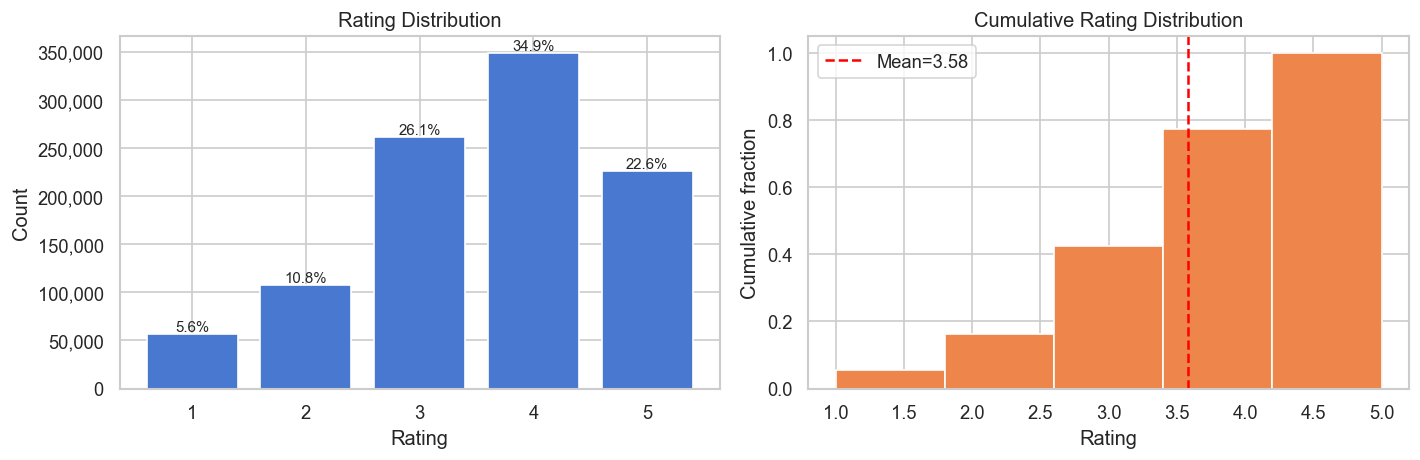

Mean: 3.582  Median: 4.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count distribution
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color=sns.color_palette('muted')[0])
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('Rating Distribution')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, (r, c) in enumerate(rating_counts.items()):
    axes[0].text(r, c + 3000, f'{c/len(ratings):.1%}', ha='center', fontsize=9)

# Cumulative
axes[1].hist(ratings['rating'], bins=5, cumulative=True, density=True,
             color=sns.color_palette('muted')[1], edgecolor='white')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('Cumulative Rating Distribution')
axes[1].axvline(ratings['rating'].mean(), color='red', linestyle='--', label=f'Mean={ratings["rating"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/evaluation/rating_distribution.png', bbox_inches='tight')
plt.show()

print(f'Mean: {ratings["rating"].mean():.3f}  Median: {ratings["rating"].median()}')

## 4. Interactions per user — the cold-start spectrum

The distribution of interactions per user is critical for understanding model failure modes.

- **Cold users** (few ratings): CF has little signal to learn from. They often get generic or
  popularity-based recommendations. Content-based models help here.
- **Hot users** (many ratings): CF can build rich latent profiles and typically outperforms
  simpler methods significantly.

Note: MovieLens 1M was pre-filtered to include only users with ≥20 ratings.
In a real system you'd have a much more extreme cold-start problem.

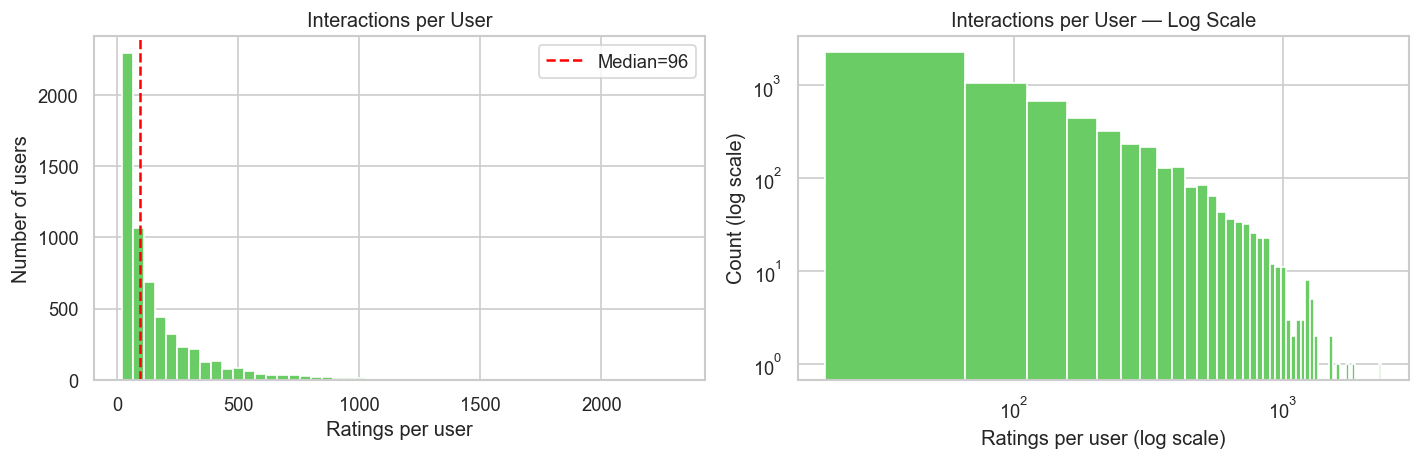

count    6040.0
mean      165.6
std       192.7
min        20.0
25%        44.0
50%        96.0
75%       208.0
max      2314.0
Name: n_ratings, dtype: float64

Cold  users (<50 ratings):    1,743  (28.9%)
Warm  users (50-199 ratings): 2,708  (44.8%)
Hot   users (≥200 ratings):   1,589  (26.3%)


In [5]:
per_user = ratings.groupby('user_id')['movie_id'].count().rename('n_ratings')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram (log scale)
axes[0].hist(per_user, bins=50, color=sns.color_palette('muted')[2], edgecolor='white')
axes[0].set_xlabel('Ratings per user')
axes[0].set_ylabel('Number of users')
axes[0].set_title('Interactions per User')
axes[0].axvline(per_user.median(), color='red', linestyle='--', label=f'Median={per_user.median():.0f}')
axes[0].legend()

# Log-log (reveals power law shape)
axes[1].hist(per_user, bins=50, color=sns.color_palette('muted')[2], edgecolor='white', log=True)
axes[1].set_xscale('log')
axes[1].set_xlabel('Ratings per user (log scale)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Interactions per User — Log Scale')

plt.tight_layout()
plt.savefig('../reports/evaluation/interactions_per_user.png', bbox_inches='tight')
plt.show()

print(per_user.describe().round(1))
print()

# User segments — these map to our evaluation breakdown in Phase 7
cold  = (per_user < 50).sum()
warm  = ((per_user >= 50) & (per_user < 200)).sum()
hot   = (per_user >= 200).sum()
print(f'Cold  users (<50 ratings):    {cold:,}  ({cold/len(per_user):.1%})')
print(f'Warm  users (50-199 ratings): {warm:,}  ({warm/len(per_user):.1%})')
print(f'Hot   users (≥200 ratings):   {hot:,}  ({hot/len(per_user):.1%})')

## 5. Interactions per movie — popularity power law

Item popularity follows a power law: a small number of movies dominate interactions.

This has two implications:
1. **Popularity bias risk**: models trained on this data will over-recommend popular movies
   because they have more training signal. Our evaluation will explicitly check for this.
2. **Popularity baseline strength**: recommending the top-K popular items will hit something
   relevant for most users. This is why we benchmark against it — if CF can't beat it,
   something is wrong.

In [ ]:
per_movie = ratings.groupby('movie_id')['user_id'].count().rename('n_ratings').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Rank vs count (log-log reveals power law)
axes[0].loglog(range(1, len(per_movie)+1), per_movie.values, color=sns.color_palette('muted')[3])
axes[0].set_xlabel('Movie rank (1 = most popular)')
axes[0].set_ylabel('Number of ratings')
axes[0].set_title('Item Popularity (Log-Log) — Power Law')
axes[0].axhline(100, color='gray', linestyle=':', label='100 ratings')
axes[0].legend()

# Top 20 most rated movies
top20 = per_movie.head(20).reset_index()
top20 = top20.merge(movies[['movie_id','title']], on='movie_id')
top20['short_title'] = top20['title'].str[:30]
axes[1].barh(top20['short_title'][::-1], top20['n_ratings'][::-1], color=sns.color_palette('muted')[3])
axes[1].set_xlabel('Number of ratings')
axes[1].set_title('Top 20 Most Rated Movies')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../reports/evaluation/item_popularity.png', bbox_inches='tight')
plt.show()

print(f'Movies with < 5 ratings:    {(per_movie < 5).sum():,}')
print(f'Movies with < 20 ratings:   {(per_movie < 20).sum():,}')
print(f'Movies with >= 500 ratings: {(per_movie >= 500).sum():,}')
print(f'Top 1% movies account for {per_movie.head(len(per_movie)//100).sum() / n_ratings:.1%} of all ratings')

## 6. Temporal distribution — validating our split strategy

We use a **time-aware split** rather than random. This is important because:
- Random splits can let the model see future interactions during training (data leakage)
- Real systems predict future behavior from past behavior — the split should reflect this

Here we verify timestamps are meaningful and span enough time to make the split worthwhile.

In [ ]:
ratings['date'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['month'] = ratings['date'].dt.to_period('M')

monthly = ratings.groupby('month').size()

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(kind='bar', ax=ax, color=sns.color_palette('muted')[4], edgecolor='white', width=0.9)
ax.set_xlabel('Month')
ax.set_ylabel('Number of ratings')
ax.set_title('Rating Volume Over Time')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
# Only show every 6th x-tick to avoid clutter
ticks = ax.get_xticks()
ax.set_xticks([t for t in ticks if t % 6 == 0])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/evaluation/ratings_over_time.png', bbox_inches='tight')
plt.show()

print(f'Date range: {ratings["date"].min().date()} to {ratings["date"].max().date()}')
print(f'Span: {len(monthly)} months')

## 7. Genre distribution

Understanding the genre landscape helps interpret content-based model behavior.
If Drama and Comedy dominate, the content model will be biased toward those genres
simply because there's more training signal there.

In [ ]:
from collections import Counter

all_genres = [g for genres in movies['genres'] for g in genres]
genre_counts = pd.Series(Counter(all_genres)).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
genre_counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted')[0], edgecolor='white')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of movies')
ax.set_title('Movie Count by Genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/evaluation/genre_distribution.png', bbox_inches='tight')
plt.show()

print('Top genres:')
print(genre_counts.head(10).to_string())

## 8. Summary — Key takeaways for modeling

| Finding | Implication |
|---|---|
| 95.5% sparsity | CF must generalize from very few observations per user |
| Rating skew high (mean 3.58) | Treat as implicit confidence, not explicit score |
| All users have ≥20 ratings | Cold-start less extreme than real systems — note in insights |
| Item popularity is power-law | Popularity bias is a real risk; evaluate separately |
| 34 months of data | Time-aware split is meaningful |
| Drama/Comedy dominate genres | Content model has uneven genre coverage |

**Next:** Phase 2 — time-aware train/val/test split using timestamps.